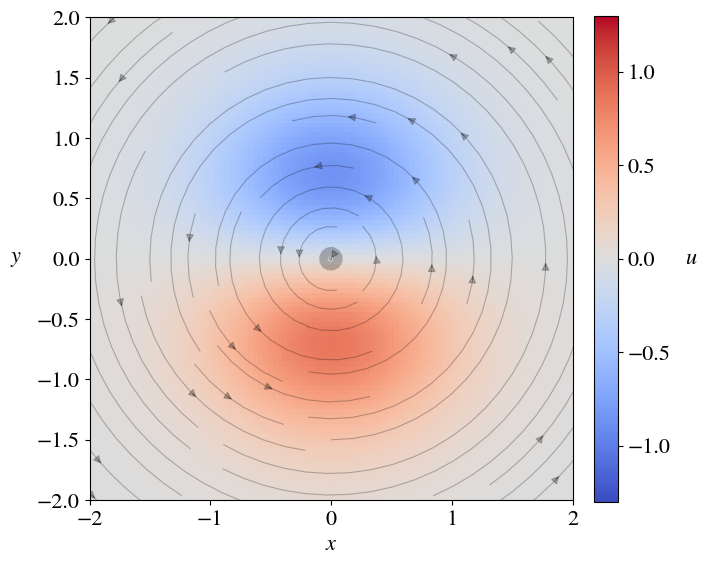

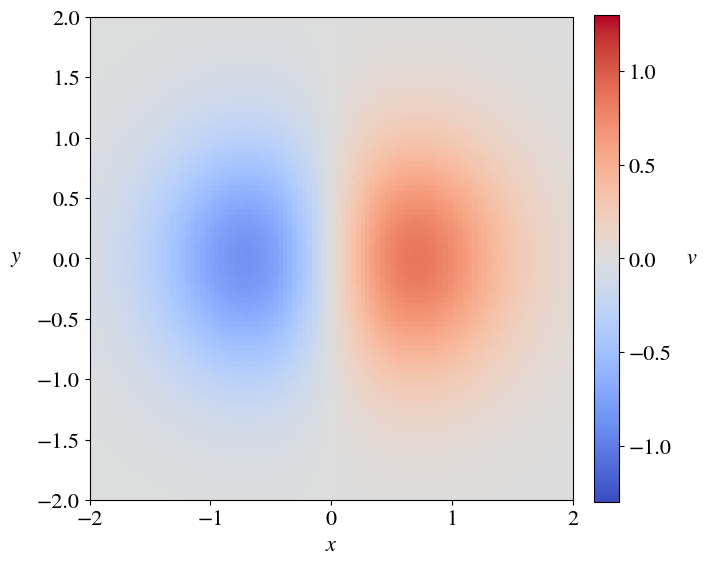

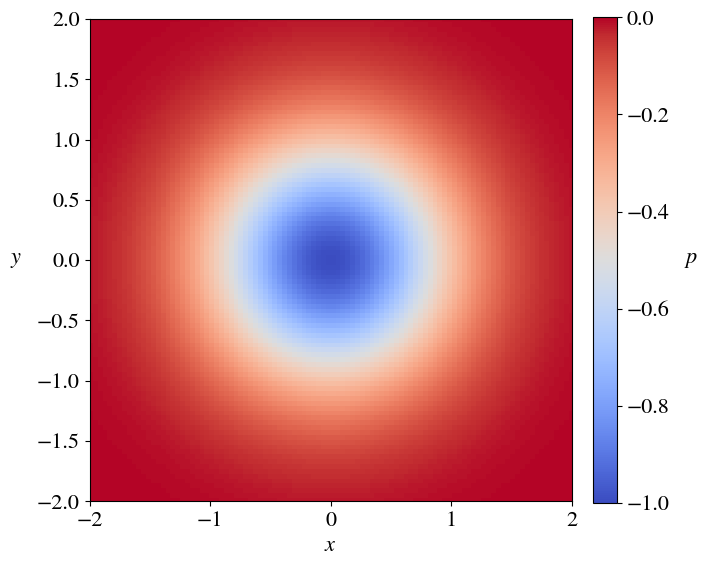

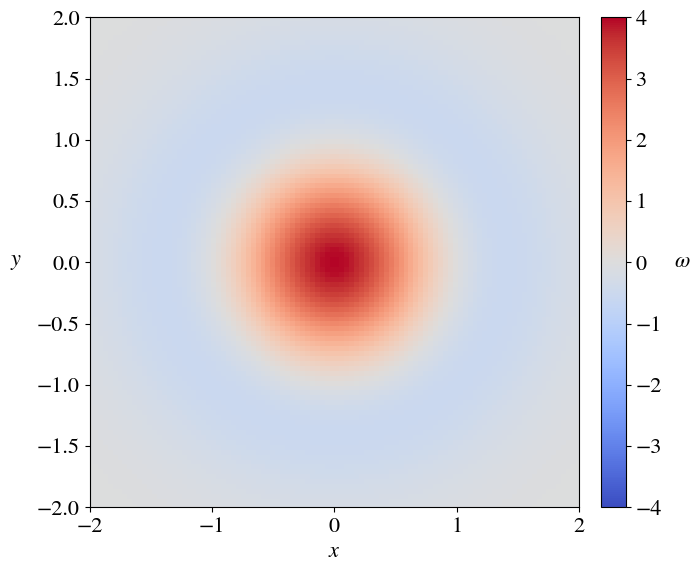

In [1]:
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt

# Visual setup
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["STIXGeneral"],
    "mathtext.fontset": "stix",
    "font.size": 16
})

# Grid
nx, ny = 150, 150 
x = np.linspace(-3, 3, nx)
y = np.linspace(-3, 3, ny)
X_grid, Y_grid = np.meshgrid(x, y)

# Exact solutions: Pressure and Velocity
# Using p = -exp(-(x^2 + y^2))
p_exact = -np.exp(-(X_grid**2 + Y_grid**2))
u_exact = -2.0 * Y_grid * np.exp(-(X_grid**2 + Y_grid**2))
v_exact =  2.0 * X_grid * np.exp(-(X_grid**2 + Y_grid**2))

# Vorticity calculation (omega = dv/dx - du/dy)
r2 = X_grid**2 + Y_grid**2
vorticity_exact = 4.0 * (1 - r2) * np.exp(-r2)

# Exportation setup (to be used in PINN or analysis)
X_star = np.stack([X_grid.flatten(), Y_grid.flatten()], axis=1)
u_star = u_exact.flatten()[:, None]
v_star = v_exact.flatten()[:, None]
p_star = p_exact.flatten()[:, None]
omega_star = vorticity_exact.flatten()[:, None]
t_star = np.zeros((X_grid.size, 1))

# Export file
output_file = 'geostrophic_cyclone_data.mat'
sio.savemat(output_file, {
    'X_star': X_star, 
    'u_star': u_star,
    'v_star': v_star,
    'p_star': p_star,
    'omega_star': omega_star,
    't': t_star
})

# Global aesthetic parameters
cmap_opt = 'coolwarm'
label_font = 16
rot_val = 0
pad_val = 15
v_lim_vel = 1.3
v_lim_pres = 1.0
v_lim_vort = 4.0

# --- Visualization: Velocity u ---
fig_u, ax_u = plt.subplots(figsize=(7, 6))
im0 = ax_u.pcolormesh(X_grid, Y_grid, u_exact, cmap=cmap_opt, 
                     shading='auto', vmin=-v_lim_vel, vmax=v_lim_vel)
cb_u = fig_u.colorbar(im0, ax=ax_u, fraction=0.046, pad=0.04)
cb_u.set_label(r'$u$', rotation=rot_val, labelpad=pad_val, fontsize=label_font, va='center')
ax_u.streamplot(x, y, u_exact, v_exact, color=(0, 0, 0, 0.25), 
                density=1.1, linewidth=0.8, arrowsize=1.2)
ax_u.set_xlabel(r'$x$', fontsize=label_font)
ax_u.set_ylabel(r'$y$', rotation=rot_val, labelpad=pad_val, fontsize=label_font, va='center')
ax_u.set_xlim(-2, 2)
ax_u.set_ylim(-2, 2)
ax_u.set_aspect('equal')
plt.tight_layout()
fig_u.savefig('Images/Geostrophic_U.png', dpi=300, bbox_inches='tight')

# --- Visualization: Velocity v ---
fig_v, ax_v = plt.subplots(figsize=(7, 6))
im1 = ax_v.pcolormesh(X_grid, Y_grid, v_exact, cmap=cmap_opt, 
                     shading='auto', vmin=-v_lim_vel, vmax=v_lim_vel)
cb_v = fig_v.colorbar(im1, ax=ax_v, fraction=0.046, pad=0.04)
cb_v.set_label(r'$v$', rotation=rot_val, labelpad=pad_val, fontsize=label_font, va='center')
ax_v.set_xlabel(r'$x$', fontsize=label_font)
ax_v.set_ylabel(r'$y$', rotation=rot_val, labelpad=pad_val, fontsize=label_font, va='center')
ax_v.set_xlim(-2, 2)
ax_v.set_ylim(-2, 2)
ax_v.set_aspect('equal')
plt.tight_layout()
fig_v.savefig('Images/Geostrophic_V.png', dpi=300, bbox_inches='tight')

# --- Visualization: Pressure p ---
fig_p, ax_p = plt.subplots(figsize=(7, 6))
im2 = ax_p.pcolormesh(X_grid, Y_grid, p_exact, cmap=cmap_opt, 
                     shading='auto', vmin=-v_lim_pres, vmax=0)
cb_p = fig_p.colorbar(im2, ax=ax_p, fraction=0.046, pad=0.04)
cb_p.set_label(r'$p$', rotation=rot_val, labelpad=pad_val, fontsize=label_font, va='center')
ax_p.set_xlabel(r'$x$', fontsize=label_font)
ax_p.set_ylabel(r'$y$', rotation=rot_val, labelpad=pad_val, fontsize=label_font, va='center')
ax_p.set_xlim(-2, 2)
ax_p.set_ylim(-2, 2)
ax_p.set_aspect('equal')
plt.tight_layout()
fig_p.savefig('Images/Geostrophic_P.png', dpi=300, bbox_inches='tight')

# --- Visualization: Vorticity omega ---
fig_w, ax_w = plt.subplots(figsize=(7, 6))
im3 = ax_w.pcolormesh(X_grid, Y_grid, vorticity_exact, cmap=cmap_opt, 
                     shading='auto', vmin=-v_lim_vort, vmax=v_lim_vort)
cb_w = fig_w.colorbar(im3, ax=ax_w, fraction=0.046, pad=0.04)
cb_w.set_label(r'$\omega$', rotation=rot_val, labelpad=pad_val, fontsize=label_font, va='center')
ax_w.set_xlabel(r'$x$', fontsize=label_font)
ax_w.set_ylabel(r'$y$', rotation=rot_val, labelpad=pad_val, fontsize=label_font, va='center')
ax_w.set_xlim(-2, 2)
ax_w.set_ylim(-2, 2)
ax_w.set_aspect('equal')
plt.tight_layout()
fig_w.savefig('Images/Geostrophic_Omega.png', dpi=300, bbox_inches='tight')

plt.show()